<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/asthma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.4 MB/s eta 0:00:00
Using FIPS code '01' for input 'AL'
Using FIPS code '02' for input 'AK'
Using FIPS code '04' for input 'AZ'
Using FIPS code '05' for input 'AR'
Using FIPS code '06' for input 'CA'
Using FIPS code '08' for input 'CO'
Using FIPS code '09' for input 'CT'
Using FIPS code '10' for input 'DE'
Using FIPS code '12' for input 'FL'
Using FIPS code '13' for input 'GA'
Using FIPS code '15' for input 'HI'
Using FIPS code '16' for input 'ID'
Using FIPS code '17' for input 'IL'
Using FIPS code '18' for input 'IN'
Using FIPS code '19' for input 'IA'
Using FIPS code '20' for input 'KS'
Using FIPS code '21' for input 'KY'
Using FIPS code '22' for input 'LA'
Using FIPS code '23' for input 'ME'
Using FIPS code '24' for input 'MD'
Using FIPS code '25' for input 'MA'
Using FIPS code '26' for input 'MI'
Using FIPS code '27' for input 'MN'
Using FIPS code '28' for input 'MS'
Using FIPS code '29' for input 'MO'
Using FIPS code '30' f

/tmp/ipykernel_803/3007277152.py:191: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = county_geom.centroid


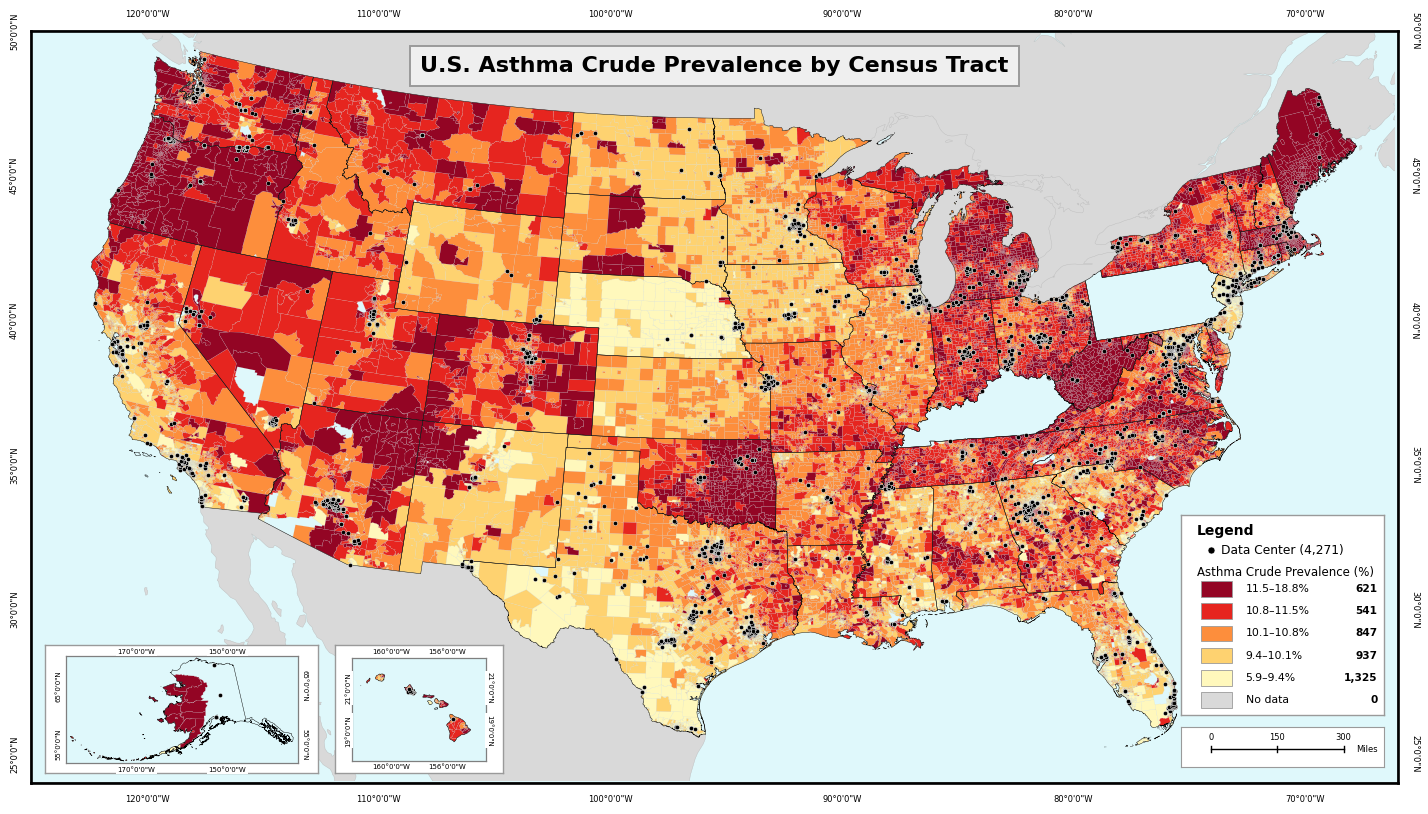

In [ ]:
!pip install numpy geopandas pandas matplotlib openpyxl shapely pygris

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import pygris

census = pd.read_csv('/content/PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2025_release_20260610.csv')

census["TRACT_GEOID"] = pd.to_numeric(census["TractFIPS"], errors="coerce").fillna(0).astype(int)
census["TRACT_GEOID"] = census["TRACT_GEOID"].astype(str).str.zfill(11)

legend_title = "Asthma Crude Prevalence (%)"
census["Data_Value"] = pd.to_numeric(census["CASTHMA_CrudePrev"], errors="coerce")

states_list = ["AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA",
               "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
               "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT",
               "VA", "WA", "WV", "WI", "WY", "DC"]

geo_tracts_list = [pygris.tracts(state=st, cb=True, year=2022, cache=True) for st in states_list]
geo = gpd.GeoDataFrame(pd.concat(geo_tracts_list, ignore_index=True))
geo["geoid_clean"] = geo["GEOID"].astype(str).str.strip()

state_borders = pygris.states(cb=True, year=2022, cache=True)

merged = geo.merge(census, left_on="geoid_clean", right_on="TRACT_GEOID", how="inner")
plot_data = merged.dropna(subset=["Data_Value"]).copy()


facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete")

# fips for data centers
facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

# bins
vmin = plot_data["Data_Value"].min()
vmax = plot_data["Data_Value"].max()

plot_data["asthma_bin"], bin_edges = pd.qcut(
    plot_data["Data_Value"],
    q=5,
    labels=False,
    retbins=True,
    duplicates="drop")

n_bins = len(bin_edges) - 1

# map split
lower48 = plot_data[~plot_data["STATEFP"].isin(["02", "15"])].copy()
alaska = plot_data[plot_data["STATEFP"] == "02"].copy()
hawaii = plot_data[plot_data["STATEFP"] == "15"].copy()

lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

lower48_states = state_borders[~state_borders["STATEFP"].isin(["02", "15", "60", "66", "69", "72", "78"])].to_crs(epsg=5070)
alaska_states = state_borders[state_borders["STATEFP"] == "02"].to_crs(epsg=3338)
hawaii_states = state_borders[state_borders["STATEFP"] == "15"].to_crs(epsg=4326)

# canada & mexico
world_url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(world_url)
world = world.to_crs(epsg=4326)

neighbor_names = ["Canada", "Mexico"]
neighbors = world[world["ADMIN"].isin(neighbor_names)].copy()
neighbors_proj = neighbors.to_crs(epsg=5070)

# lakes
lakes_url = "https://naciscdn.org/naturalearth/50m/physical/ne_50m_lakes.zip"
lakes = gpd.read_file(lakes_url)
lakes = lakes.to_crs(epsg=4326)

great_lakes_names = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron",
    "Lake Erie",
    "Lake Ontario"]
great_lakes = lakes[lakes["name"].isin(great_lakes_names)].copy()
great_lakes_proj = great_lakes.to_crs(epsg=5070)

# colors
color_anchors = ["#FFFFCC", "#FED976", "#FD8D3C", "#E31A1C", "#800026"]
missing_color = "#D9D9D9"

tier_cmap = mcolors.LinearSegmentedColormap.from_list("tier_cmap", color_anchors)

color_positions = np.linspace(0.05, 0.95, n_bins) if n_bins > 1 else [0.5]
colors = [mcolors.to_hex(tier_cmap(p)) for p in color_positions]

tier_names = [f"{bin_edges[i]:.1f}\u2013{bin_edges[i + 1]:.1f}%" for i in range(n_bins)]


def plot_asthma_map(ax, gdf, linewidth):
    missing = gdf[gdf["asthma_bin"].isna()]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=2)

    for i in range(n_bins):
        bin_df = gdf[gdf["asthma_bin"] == i]

        if not bin_df.empty:
            bin_df.plot(
                color=colors[i],
                edgecolor="lightgray",
                linewidth=linewidth,
                ax=ax,
                zorder=3 )


def build_county_dissolve(tract_gdf):
    tmp = tract_gdf[["GEOID", "geometry"]].copy()
    tmp["county_fips"] = tmp["GEOID"].astype(str).str[:5]
    tmp = tmp.drop(columns=["GEOID"])
    dissolved = tmp.dissolve(by="county_fips")
    dissolved = dissolved.reset_index().rename(columns={"county_fips": "GEOID"})
    return dissolved[["GEOID", "geometry"]]


# facility locations
def build_facility_points(facilities_df, county_gdf, target_crs):
    df = facilities_df[facilities_df["fips"].isin(county_gdf["GEOID"])].copy()

    df = df.merge(
        county_gdf[["GEOID", "geometry"]].rename(columns={"geometry": "county_geom"}),
        left_on="fips",
        right_on="GEOID",
        how="left")

    county_geom = gpd.GeoSeries(
        df["county_geom"].values,
        crs=target_crs,
        index=df.index).buffer(0)

    # facility to county
    points = county_geom.centroid

    coords_ok = df["latitude"].notna() & df["longitude"].notna()

    if coords_ok.any():
        geocoded = gpd.GeoSeries(
            gpd.points_from_xy(
                df.loc[coords_ok, "longitude"],
                df.loc[coords_ok, "latitude"]),
            crs="EPSG:4326",
            index=df.loc[coords_ok].index).to_crs(target_crs)
        inside = geocoded.within(county_geom.loc[coords_ok])
        good_idx = geocoded.index[inside]
        points.loc[good_idx] = geocoded.loc[good_idx]

    return gpd.GeoDataFrame(
        df.drop(columns=["county_geom", "GEOID"]),
        geometry=points,
        crs=target_crs)


def facility_tier_bins(facility_points, tract_proj):
    if facility_points.empty:
        return pd.Series(dtype="float64")

    joined = gpd.sjoin(
        facility_points,
        tract_proj[["asthma_bin", "geometry"]],
        how="left",
        predicate="within")
    return joined["asthma_bin"]


# label helpers
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1

    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}\u00b0{minutes}'{seconds}\"{direction}"


def add_dms_frame_labels(
    ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6,
    on_line=False,
    top_inset=0.0,
    bottom_inset=0.0,
    left_inset=0.0,
    right_inset=0.0):
    if on_line:
        top_y, bottom_y = 1.0 - top_inset, 0.0 + bottom_inset
        va_top, va_bottom = "center", "center"
        left_x, right_x = 0.0 + left_inset, 1.0 - right_inset
        ha_left, ha_right = "center", "center"
        label_bbox = dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0 )
    else:
        top_y, bottom_y = 1.016, -0.016
        va_top, va_bottom = "bottom", "top"
        left_x, right_x = -0.009, 1.009
        ha_left, ha_right = "right", "left"
        label_bbox = None

    for lon in lon_values:
        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac, top_y, label,
            transform=ax.transAxes, ha="center", va=va_top,
            fontsize=lon_fontsize, color="black", clip_on=False,
            bbox=label_bbox, zorder=30)

        ax.text(
            x_frac, bottom_y, label,
            transform=ax.transAxes, ha="center", va=va_bottom,
            fontsize=lon_fontsize, color="black", clip_on=False,
            bbox=label_bbox, zorder=30)

    for lat in lat_values:
        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            left_x, y_frac, label,
            transform=ax.transAxes, ha=ha_left, va="center", rotation=90,
            fontsize=lat_fontsize, color="black", clip_on=False,
            bbox=label_bbox, zorder=30)

        ax.text(
            right_x, y_frac, label,
            transform=ax.transAxes, ha=ha_right, va="center", rotation=270,
            fontsize=lat_fontsize, color="black", clip_on=False,
            bbox=label_bbox, zorder=30)


def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles", bar_end=0.85):
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#9a9a9a")

    ax.set_xticks([])
    ax.set_yticks([])

    bar_start = 0.15
    bar_mid = (bar_start + bar_end) / 2

    # main scale
    ax.plot([bar_start, bar_end], [0.45, 0.45], color="black", linewidth=1.0)

    # tick marks
    ax.plot([bar_start, bar_start], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([bar_mid, bar_mid], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([bar_end, bar_end], [0.38, 0.52], color="black", linewidth=1.0)

    # lables
    ax.text(bar_start, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
    ax.text(bar_mid, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
    ax.text(bar_end, 0.62, labels[2], ha="center", va="bottom", fontsize=6)

    # right-aligned
    ax.text(0.97, 0.45, unit, ha="right", va="center", fontsize=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


# facility locations
county_lower48 = build_county_dissolve(lower48_proj)
county_alaska = build_county_dissolve(alaska_proj)
county_hawaii = build_county_dissolve(hawaii_proj)

facility_points_lower48 = build_facility_points(facilities, county_lower48, lower48_proj.crs)
facility_points_alaska = build_facility_points(facilities, county_alaska, alaska_proj.crs)
facility_points_hawaii = build_facility_points(facilities, county_hawaii, hawaii_proj.crs)

facility_bins_all = pd.concat([
    facility_tier_bins(facility_points_lower48, lower48_proj),
    facility_tier_bins(facility_points_alaska, alaska_proj),
    facility_tier_bins(facility_points_hawaii, hawaii_proj)])

facility_tier_counts = [int((facility_bins_all == i).sum()) for i in range(n_bins)]
facility_no_data_count = int(facility_bins_all.isna().sum())

# plot
fig = plt.figure(figsize=(14, 8), facecolor="white")

ax_frame_bg = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=0)
ax_frame_bg.set_facecolor("#dff8fb")

for spine in ax_frame_bg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame_bg.set_xticks([])
ax_frame_bg.set_yticks([])

# main us map
ax_main = fig.add_axes([0.014, 0.032, 0.972, 0.936], zorder=2)
ax_main.set_facecolor("#dff8fb")

neighbors_proj.plot(
    ax=ax_main,
    color="#d9d9d9",
    edgecolor="#bcbcbc",
    linewidth=0.3,
    zorder=1)

great_lakes_proj.plot(
    ax=ax_main,
    color="#d9d9d9",
    edgecolor="#bcbcbc",
    linewidth=0.3,
    zorder=1)

plot_asthma_map(ax_main, lower48_proj, 0.08)

lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.30,
    zorder=4)

facility_points_lower48.plot(
    ax=ax_main,
    color="black",
    markersize=9,
    marker="o",
    edgecolor="white",
    linewidth=0.3,
    zorder=6)

minx, miny, maxx, maxy = lower48_proj.total_bounds
x_buffer_left = (maxx - minx) * 0.045
x_buffer_right = (maxx - minx) * 0.030
y_buffer_top = (maxy - miny) * 0.025
y_buffer_bottom = (maxy - miny) * 0.050

ax_main.set_xlim(minx - x_buffer_left, maxx + x_buffer_right)
ax_main.set_ylim(miny - y_buffer_bottom, maxy + y_buffer_top)

ax_main.set_aspect("auto")

for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xticks([])
ax_main.set_yticks([])

# alaska: outer box
ak_outer = fig.add_axes([0.022, 0.042, 0.195, 0.160], zorder=4)
ak_outer.set_facecolor("white")

for spine in ak_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ak_outer.set_xticks([])
ak_outer.set_yticks([])

ak_inner_left = 0.075
ak_inner_bottom = 0.080
ak_inner_width = 0.850
ak_inner_height = 0.840

ax_ak = ak_outer.inset_axes([ak_inner_left, ak_inner_bottom, ak_inner_width, ak_inner_height])
ax_ak.set_facecolor("#dff8fb")

# alaska smear
if not alaska_proj.empty:
    alaska_proj_clean = alaska_proj[alaska_proj.geometry.centroid.x < 0]
    plot_asthma_map(ax_ak, alaska_proj_clean, 0.10)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.32,
    zorder=4)

facility_points_alaska.plot(
    ax=ax_ak,
    color="black",
    markersize=9,
    marker="o",
    edgecolor="white",
    linewidth=0.3,
    zorder=6)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.02
y_buffer = (maxy - miny) * 0.02

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

ax_ak.set_aspect("auto")

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

add_dms_frame_labels(
    ax=ak_outer,
    lon_values=[-170, -150],
    lat_values=[55, 65],
    lon_min=-190, lon_max=-130, lat_min=50, lat_max=72,
    lon_fontsize=5, lat_fontsize=5,
    on_line=True,
    top_inset=0.05, bottom_inset=0.03, left_inset=0.05, right_inset=0.05)

# hawaii: outer box
hi_outer = fig.add_axes([0.229, 0.042, 0.12, 0.160], zorder=4)
hi_outer.set_facecolor("white")

for spine in hi_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

hi_outer.set_xticks([])
hi_outer.set_yticks([])

hi_inner_left = 0.045
hi_inner_bottom = 0.100
hi_inner_width = 0.910
hi_inner_height = 0.800

ax_hi = hi_outer.inset_axes([hi_inner_left, hi_inner_bottom, hi_inner_width, hi_inner_height])
ax_hi.set_facecolor("#dff8fb")

plot_asthma_map(ax_hi, hawaii_proj, 0.10)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.32,
    zorder=4)

facility_points_hawaii.plot(
    ax=ax_hi,
    color="black",
    markersize=9,
    marker="o",
    edgecolor="white",
    linewidth=0.3,
    zorder=6)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

add_dms_frame_labels(
    ax=hi_outer,
    lon_values=[-160, -156],
    lat_values=[19, 21],
    lon_min=-164, lon_max=-152, lat_min=17, lat_max=23,
    lon_fontsize=5, lat_fontsize=5,
    on_line=True,
    top_inset=0.05, bottom_inset=0.05, left_inset=0.08, right_inset=0.08)

# scale bar
MILES_PER_METER = 1 / 1609.344
legend_box_width = 0.145

main_width_in = ax_main.get_position().width * fig.get_figwidth()
main_xlim = ax_main.get_xlim()
miles_per_inch = (main_xlim[1] - main_xlim[0]) * MILES_PER_METER / main_width_in

bar_span_in = 0.70 * (legend_box_width * fig.get_figwidth())
max_miles = miles_per_inch * bar_span_in

nice_steps = [10, 20, 25, 50, 100, 150, 200, 250, 300, 400, 500, 600, 750, 1000, 1500, 2000, 2500]
scale_miles = max(step for step in nice_steps if step <= max_miles)
bar_end = 0.15 + 0.70 * (scale_miles / max_miles)

# scale bar: box
ax_scale = fig.add_axes([0.833, 0.050, legend_box_width, 0.050], zorder=4)
draw_scale_box(
    ax_scale,
    labels=("0", str(scale_miles // 2), str(scale_miles)),
    unit="Miles",
    bar_end=bar_end)

# legend box: title, data center total, and tier colors
total_facility_count = len(facility_bins_all)

ax_leg = fig.add_axes([0.833, 0.115, legend_box_width, 0.250], zorder=4)
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)

# legend title
ax_leg.text(
    0.08,
    0.955,
    "Legend",
    transform=ax_leg.transAxes,
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top")

# total count of data center amount
data_center_label = f"Data Center ({total_facility_count:,})"

dc_text = ax_leg.text(
    0.5,
    0.825,
    data_center_label,
    transform=ax_leg.transAxes,
    fontsize=8.8,
    ha="center",
    va="center")

fig.canvas.draw()
inv = ax_leg.transAxes.inverted()
dc_text_box = dc_text.get_window_extent(renderer=fig.canvas.get_renderer())
dc_text_left = inv.transform((dc_text_box.x0, 0))[0]

marker_gap = 0.03
marker_diameter = 0.039
marker_x = dc_text_left - marker_gap - marker_diameter / 2

ax_leg.scatter(
    [marker_x],
    [0.825],
    transform=ax_leg.transAxes,
    color="black",
    s=26,
    marker="o",
    edgecolor="white",
    linewidth=0.5,
    clip_on=False,
    zorder=5)

# title for color key
ax_leg.text(
    0.08,
    0.745,
    legend_title,
    transform=ax_leg.transAxes,
    fontsize=8.5,
    ha="left",
    va="top")

# color key & data center count
tier_rows = (
    list(zip(tier_names[::-1], colors[::-1], facility_tier_counts[::-1]))
    + [("No data", missing_color, facility_no_data_count)])

row_ys = np.linspace(0.63, 0.075, len(tier_rows))
swatch_w, swatch_h = 0.155, 0.078

for (label, color, count), y in zip(tier_rows, row_ys):
    ax_leg.add_patch(
        Rectangle(
            (0.10, y - swatch_h / 2),
            swatch_w,
            swatch_h,
            transform=ax_leg.transAxes,
            facecolor=color,
            edgecolor="#9a9a9a",
            linewidth=0.6,
            clip_on=False))

    ax_leg.text(
        0.32,
        y,
        label,
        transform=ax_leg.transAxes,
        ha="left",
        va="center",
        fontsize=7.8)

    ax_leg.text(
        0.97,
        y,
        f"{count:,}",
        transform=ax_leg.transAxes,
        ha="right",
        va="center",
        fontsize=7.6,
        fontweight="bold")

# frame for border, coordinate labels, and title
ax_frame = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=10)
ax_frame.patch.set_alpha(0)

for spine in ax_frame.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.9)
    spine.set_edgecolor("black")

ax_frame.set_xticks([])
ax_frame.set_yticks([])

add_dms_frame_labels(
    ax=ax_frame,
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125, lon_max=-66, lat_min=24, lat_max=50,
    lon_fontsize=6, lat_fontsize=6)

ax_frame.text(
    0.5, 0.953,
    "U.S. Asthma Crude Prevalence by Census Tract",
    transform=ax_frame.transAxes,
    ha="center", va="center",
    fontsize=16, fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=20)

plt.show()

# import numpy as np
# import geopandas as gpd
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from matplotlib.patches import Rectangle
# import pygris

# # ---------------------------------------------------------------------
# # PLACES / asthma prevalence data (tract level)
# # ---------------------------------------------------------------------
# census = pd.read_csv('/content/PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2025_release_20260610.csv')

# census["TRACT_GEOID"] = pd.to_numeric(census["TractFIPS"], errors="coerce").fillna(0).astype(int)
# census["TRACT_GEOID"] = census["TRACT_GEOID"].astype(str).str.zfill(11)

# legend_title = "Asthma Crude Prevalence (%)"
# census["Data_Value"] = pd.to_numeric(census["CASTHMA_CrudePrev"], errors="coerce")

# states_list = ["AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA",
#                "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
#                "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT",
#                "VA", "WA", "WV", "WI", "WY", "DC"]

# geo_tracts_list = [pygris.tracts(state=st, cb=True, year=2022, cache=True) for st in states_list]
# geo = gpd.GeoDataFrame(pd.concat(geo_tracts_list, ignore_index=True))
# geo["geoid_clean"] = geo["GEOID"].astype(str).str.strip()

# state_borders = pygris.states(cb=True, year=2022, cache=True)

# merged = geo.merge(census, left_on="geoid_clean", right_on="TRACT_GEOID", how="inner")
# plot_data = merged.dropna(subset=["Data_Value"]).copy()

# # ---------------------------------------------------------------------
# # Facility / data center locations (ported from the air-pollution script)
# # ---------------------------------------------------------------------
# facilities_file = "/content/facilities_final_complete.xlsx"

# facilities = pd.read_excel(
#     facilities_file,
#     sheet_name="facilities_final_complete"
# )

# # Facilities are only tagged with a 5-digit county FIPS, but this map is
# # built at the census-tract level, so matching happens at the county
# # level (tract GEOID's first 5 digits) and exact placement still uses
# # each facility's lat/lon when available.
# facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

# # ---------------------------------------------------------------------
# # Bins (quintiles, same methodology as before)
# # ---------------------------------------------------------------------
# vmin = plot_data["Data_Value"].min()
# vmax = plot_data["Data_Value"].max()

# plot_data["asthma_bin"], bin_edges = pd.qcut(
#     plot_data["Data_Value"],
#     q=5,
#     labels=False,
#     retbins=True,
#     duplicates="drop"
# )

# n_bins = len(bin_edges) - 1

# # ---------------------------------------------------------------------
# # Split into maps
# # ---------------------------------------------------------------------
# lower48 = plot_data[~plot_data["STATEFP"].isin(["02", "15"])].copy()
# alaska = plot_data[plot_data["STATEFP"] == "02"].copy()
# hawaii = plot_data[plot_data["STATEFP"] == "15"].copy()

# lower48_proj = lower48.to_crs(epsg=5070)
# alaska_proj = alaska.to_crs(epsg=3338)
# hawaii_proj = hawaii.to_crs(epsg=4326)

# lower48_states = state_borders[~state_borders["STATEFP"].isin(["02", "15", "60", "66", "69", "72", "78"])].to_crs(epsg=5070)
# alaska_states = state_borders[state_borders["STATEFP"] == "02"].to_crs(epsg=3338)
# hawaii_states = state_borders[state_borders["STATEFP"] == "15"].to_crs(epsg=4326)

# # ---------------------------------------------------------------------
# # Load neighboring countries (Canada and Mexico) for background context,
# # shown greyed out -- same source/approach as the air-pollution script
# # ---------------------------------------------------------------------
# world_url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
# world = gpd.read_file(world_url)
# world = world.to_crs(epsg=4326)

# neighbor_names = ["Canada", "Mexico"]
# neighbors = world[world["ADMIN"].isin(neighbor_names)].copy()
# neighbors_proj = neighbors.to_crs(epsg=5070)

# # Load major lakes (Great Lakes, etc.) for background context, shown
# # greyed out just like Canada and Mexico
# lakes_url = "https://naciscdn.org/naturalearth/50m/physical/ne_50m_lakes.zip"
# lakes = gpd.read_file(lakes_url)
# lakes = lakes.to_crs(epsg=4326)

# great_lakes_names = [
#     "Lake Superior",
#     "Lake Michigan",
#     "Lake Huron",
#     "Lake Erie",
#     "Lake Ontario"
# ]
# great_lakes = lakes[lakes["name"].isin(great_lakes_names)].copy()
# great_lakes_proj = great_lakes.to_crs(epsg=5070)

# # ---------------------------------------------------------------------
# # Colors for asthma-prevalence tiers, low -> high, plus a separate
# # color for tracts with no data -- same yellow -> orange -> red family
# # used for PM2.5. Tier count/labels are built dynamically from the
# # quintile edges in case duplicates="drop" ever collapses a bin.
# # ---------------------------------------------------------------------
# color_anchors = ["#FFFFCC", "#FED976", "#FD8D3C", "#E31A1C", "#800026"]
# missing_color = "#D9D9D9"

# tier_cmap = mcolors.LinearSegmentedColormap.from_list("tier_cmap", color_anchors)

# color_positions = np.linspace(0.05, 0.95, n_bins) if n_bins > 1 else [0.5]
# colors = [mcolors.to_hex(tier_cmap(p)) for p in color_positions]

# tier_names = [f"{bin_edges[i]:.1f}\u2013{bin_edges[i + 1]:.1f}%" for i in range(n_bins)]


# def plot_asthma_map(ax, gdf, linewidth):
#     missing = gdf[gdf["asthma_bin"].isna()]

#     if not missing.empty:
#         missing.plot(
#             color=missing_color,
#             edgecolor="lightgray",
#             linewidth=linewidth,
#             ax=ax,
#             zorder=2
#         )

#     for i in range(n_bins):
#         bin_df = gdf[gdf["asthma_bin"] == i]

#         if not bin_df.empty:
#             bin_df.plot(
#                 color=colors[i],
#                 edgecolor="lightgray",
#                 linewidth=linewidth,
#                 ax=ax,
#                 zorder=3
#             )


# # ---------------------------------------------------------------------
# # Facility helpers (ported from the air-pollution script)
# # ---------------------------------------------------------------------
# def build_county_dissolve(tract_gdf):
#     """Collapse a projected tract layer down to one polygon per county
#     (first 5 digits of the tract GEOID) so facilities -- which only
#     carry a county FIPS -- can be matched/placed the same way the
#     air-pollution script matched them directly against county polygons.
#     """
#     tmp = tract_gdf[["GEOID", "geometry"]].copy()
#     tmp["county_fips"] = tmp["GEOID"].astype(str).str[:5]
#     # Drop the original tract-level GEOID before dissolving, otherwise
#     # renaming county_fips -> GEOID collides with it and leaves two
#     # columns with the same name.
#     tmp = tmp.drop(columns=["GEOID"])
#     dissolved = tmp.dissolve(by="county_fips")
#     dissolved = dissolved.reset_index().rename(columns={"county_fips": "GEOID"})
#     return dissolved[["GEOID", "geometry"]]


# # Turn facility lat/lon into map points in a given projected CRS.
# def build_facility_points(facilities_df, county_gdf, target_crs):
#     df = facilities_df[facilities_df["fips"].isin(county_gdf["GEOID"])].copy()

#     df = df.merge(
#         county_gdf[["GEOID", "geometry"]].rename(columns={"geometry": "county_geom"}),
#         left_on="fips",
#         right_on="GEOID",
#         how="left"
#     )

#     county_geom = gpd.GeoSeries(
#         df["county_geom"].values,
#         crs=target_crs,
#         index=df.index
#     ).buffer(0)

#     # Default every facility to its county's centroid
#     points = county_geom.centroid

#     coords_ok = df["latitude"].notna() & df["longitude"].notna()

#     if coords_ok.any():
#         geocoded = gpd.GeoSeries(
#             gpd.points_from_xy(
#                 df.loc[coords_ok, "longitude"],
#                 df.loc[coords_ok, "latitude"]
#             ),
#             crs="EPSG:4326",
#             index=df.loc[coords_ok].index
#         ).to_crs(target_crs)

#         # Only trust the geocoded point if it actually lands inside
#         # the county it's supposed to belong to
#         inside = geocoded.within(county_geom.loc[coords_ok])
#         good_idx = geocoded.index[inside]
#         points.loc[good_idx] = geocoded.loc[good_idx]

#     return gpd.GeoDataFrame(
#         df.drop(columns=["county_geom", "GEOID"]),
#         geometry=points,
#         crs=target_crs
#     )


# def facility_tier_bins(facility_points, tract_proj):
#     """Spatially join facility points to the tract they fall in, so the
#     legend can report which asthma-prevalence tier each facility
#     actually sits in (tract-level bins, not the county-level fallback
#     used for placement).
#     """
#     if facility_points.empty:
#         return pd.Series(dtype="float64")

#     joined = gpd.sjoin(
#         facility_points,
#         tract_proj[["asthma_bin", "geometry"]],
#         how="left",
#         predicate="within"
#     )
#     return joined["asthma_bin"]


# # ---------------------------------------------------------------------
# # Coordinate label helpers (ported from the air-pollution script)
# # ---------------------------------------------------------------------
# def decimal_to_dms(value, is_lon=True):
#     if is_lon:
#         direction = "W" if value < 0 else "E"
#     else:
#         direction = "S" if value < 0 else "N"

#     value = abs(value)
#     degrees = int(value)
#     minutes_float = (value - degrees) * 60
#     minutes = int(minutes_float)
#     seconds = int(round((minutes_float - minutes) * 60))

#     if seconds == 60:
#         seconds = 0
#         minutes += 1

#     if minutes == 60:
#         minutes = 0
#         degrees += 1

#     return f"{degrees}\u00b0{minutes}'{seconds}\"{direction}"


# def add_dms_frame_labels(
#     ax,
#     lon_values,
#     lat_values,
#     lon_min,
#     lon_max,
#     lat_min,
#     lat_max,
#     lon_fontsize=6,
#     lat_fontsize=6,
#     on_line=False,
#     top_inset=0.0,
#     bottom_inset=0.0,
#     left_inset=0.0,
#     right_inset=0.0
# ):
#     if on_line:
#         top_y, bottom_y = 1.0 - top_inset, 0.0 + bottom_inset
#         va_top, va_bottom = "center", "center"
#         left_x, right_x = 0.0 + left_inset, 1.0 - right_inset
#         ha_left, ha_right = "center", "center"
#         label_bbox = dict(
#             facecolor="white",
#             edgecolor="none",
#             pad=1.0
#         )
#     else:
#         top_y, bottom_y = 1.004, -0.004
#         va_top, va_bottom = "bottom", "top"
#         left_x, right_x = -0.004, 1.004
#         ha_left, ha_right = "right", "left"
#         label_bbox = None

#     for lon in lon_values:
#         x_frac = (lon - lon_min) / (lon_max - lon_min)
#         label = decimal_to_dms(lon, is_lon=True)

#         ax.text(
#             x_frac, top_y, label,
#             transform=ax.transAxes, ha="center", va=va_top,
#             fontsize=lon_fontsize, color="black", clip_on=False,
#             bbox=label_bbox, zorder=30
#         )

#         ax.text(
#             x_frac, bottom_y, label,
#             transform=ax.transAxes, ha="center", va=va_bottom,
#             fontsize=lon_fontsize, color="black", clip_on=False,
#             bbox=label_bbox, zorder=30
#         )

#     for lat in lat_values:
#         y_frac = (lat - lat_min) / (lat_max - lat_min)
#         label = decimal_to_dms(lat, is_lon=False)

#         ax.text(
#             left_x, y_frac, label,
#             transform=ax.transAxes, ha=ha_left, va="center", rotation=90,
#             fontsize=lat_fontsize, color="black", clip_on=False,
#             bbox=label_bbox, zorder=30
#         )

#         ax.text(
#             right_x, y_frac, label,
#             transform=ax.transAxes, ha=ha_right, va="center", rotation=270,
#             fontsize=lat_fontsize, color="black", clip_on=False,
#             bbox=label_bbox, zorder=30
#         )


# def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles"):
#     ax.set_facecolor("white")

#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_linewidth(0.8)
#         spine.set_edgecolor("#9a9a9a")

#     ax.set_xticks([])
#     ax.set_yticks([])

#     ax.plot([0.15, 0.85], [0.45, 0.45], color="black", linewidth=1.0)
#     ax.plot([0.15, 0.15], [0.38, 0.52], color="black", linewidth=1.0)
#     ax.plot([0.50, 0.50], [0.38, 0.52], color="black", linewidth=1.0)
#     ax.plot([0.85, 0.85], [0.38, 0.52], color="black", linewidth=1.0)

#     ax.text(0.15, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
#     ax.text(0.50, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
#     ax.text(0.85, 0.62, labels[2], ha="center", va="bottom", fontsize=6)
#     ax.text(0.90, 0.45, unit, ha="left", va="center", fontsize=6)

#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 1)


# # ---------------------------------------------------------------------
# # Pre-compute facility points + tier counts for the legend.
# # Facility placement uses the full Alaska tract set (not the centroid-
# # filtered layer used only to fix the map's Aleutian rendering below).
# # ---------------------------------------------------------------------
# county_lower48 = build_county_dissolve(lower48_proj)
# county_alaska = build_county_dissolve(alaska_proj)
# county_hawaii = build_county_dissolve(hawaii_proj)

# facility_points_lower48 = build_facility_points(facilities, county_lower48, lower48_proj.crs)
# facility_points_alaska = build_facility_points(facilities, county_alaska, alaska_proj.crs)
# facility_points_hawaii = build_facility_points(facilities, county_hawaii, hawaii_proj.crs)

# facility_bins_all = pd.concat([
#     facility_tier_bins(facility_points_lower48, lower48_proj),
#     facility_tier_bins(facility_points_alaska, alaska_proj),
#     facility_tier_bins(facility_points_hawaii, hawaii_proj)
# ])

# facility_tier_counts = [int((facility_bins_all == i).sum()) for i in range(n_bins)]
# facility_no_data_count = int(facility_bins_all.isna().sum())

# # ---------------------------------------------------------------------
# # Figure layout (matches the air-pollution script's layout/sizing)
# # ---------------------------------------------------------------------
# fig = plt.figure(figsize=(14, 8), facecolor="white")

# ax_frame_bg = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=0)
# ax_frame_bg.set_facecolor("#dff8fb")

# for spine in ax_frame_bg.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.2)
#     spine.set_edgecolor("#7f7f7f")

# ax_frame_bg.set_xticks([])
# ax_frame_bg.set_yticks([])

# # Main lower 48 map
# ax_main = fig.add_axes([0.014, 0.032, 0.972, 0.936], zorder=2)
# ax_main.set_facecolor("#dff8fb")

# neighbors_proj.plot(
#     ax=ax_main,
#     color="#d9d9d9",
#     edgecolor="#bcbcbc",
#     linewidth=0.3,
#     zorder=1
# )

# great_lakes_proj.plot(
#     ax=ax_main,
#     color="#d9d9d9",
#     edgecolor="#bcbcbc",
#     linewidth=0.3,
#     zorder=1
# )

# plot_asthma_map(ax_main, lower48_proj, 0.08)

# lower48_states.boundary.plot(
#     ax=ax_main,
#     color="black",
#     linewidth=0.30,
#     zorder=4
# )

# facility_points_lower48.plot(
#     ax=ax_main,
#     color="black",
#     markersize=9,
#     marker="o",
#     edgecolor="white",
#     linewidth=0.3,
#     zorder=6
# )

# minx, miny, maxx, maxy = lower48_proj.total_bounds
# x_buffer_left = (maxx - minx) * 0.045
# x_buffer_right = (maxx - minx) * 0.030
# y_buffer_top = (maxy - miny) * 0.025
# y_buffer_bottom = (maxy - miny) * 0.050

# ax_main.set_xlim(minx - x_buffer_left, maxx + x_buffer_right)
# ax_main.set_ylim(miny - y_buffer_bottom, maxy + y_buffer_top)

# ax_main.set_aspect("auto")

# for spine in ax_main.spines.values():
#     spine.set_visible(False)

# ax_main.set_xticks([])
# ax_main.set_yticks([])

# # Alaska outer white box
# ak_outer = fig.add_axes([0.012, 0.062, 0.195, 0.140], zorder=4)
# ak_outer.set_facecolor("white")

# for spine in ak_outer.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.0)
#     spine.set_edgecolor("#9a9a9a")

# ak_outer.set_xticks([])
# ak_outer.set_yticks([])

# ak_inner_left = 0.075
# ak_inner_bottom = 0.080
# ak_inner_width = 0.850
# ak_inner_height = 0.840

# ax_ak = ak_outer.inset_axes([ak_inner_left, ak_inner_bottom, ak_inner_width, ak_inner_height])
# ax_ak.set_facecolor("#dff8fb")

# # Same fix as the original script: drop tracts whose centroid wraps to
# # the eastern hemisphere in this projection before plotting the fill,
# # so the Aleutians don't smear across the inset. State lines and
# # facility dots still use the full, unfiltered Alaska layer.
# if not alaska_proj.empty:
#     alaska_proj_clean = alaska_proj[alaska_proj.geometry.centroid.x < 0]
#     plot_asthma_map(ax_ak, alaska_proj_clean, 0.10)

# alaska_states.boundary.plot(
#     ax=ax_ak,
#     color="black",
#     linewidth=0.32,
#     zorder=4
# )

# facility_points_alaska.plot(
#     ax=ax_ak,
#     color="black",
#     markersize=9,
#     marker="o",
#     edgecolor="white",
#     linewidth=0.3,
#     zorder=6
# )

# minx, miny, maxx, maxy = alaska_proj.total_bounds
# x_buffer = (maxx - minx) * 0.02
# y_buffer = (maxy - miny) * 0.02

# ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
# ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

# ax_ak.set_aspect("auto")

# for spine in ax_ak.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(0.9)
#     spine.set_edgecolor("#7f7f7f")

# ax_ak.set_xticks([])
# ax_ak.set_yticks([])

# add_dms_frame_labels(
#     ax=ak_outer,
#     lon_values=[-170, -150],
#     lat_values=[55, 65],
#     lon_min=-190, lon_max=-130, lat_min=50, lat_max=72,
#     lon_fontsize=5, lat_fontsize=5,
#     on_line=True,
#     top_inset=0.05, bottom_inset=0.03, left_inset=0.05, right_inset=0.05
# )

# # Hawaii outer white box
# hi_outer = fig.add_axes([0.215, 0.062, 0.11, 0.140], zorder=4)
# hi_outer.set_facecolor("white")

# for spine in hi_outer.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.0)
#     spine.set_edgecolor("#9a9a9a")

# hi_outer.set_xticks([])
# hi_outer.set_yticks([])

# hi_inner_left = 0.045
# hi_inner_bottom = 0.100
# hi_inner_width = 0.910
# hi_inner_height = 0.800

# ax_hi = hi_outer.inset_axes([hi_inner_left, hi_inner_bottom, hi_inner_width, hi_inner_height])
# ax_hi.set_facecolor("#dff8fb")

# plot_asthma_map(ax_hi, hawaii_proj, 0.10)

# hawaii_states.boundary.plot(
#     ax=ax_hi,
#     color="black",
#     linewidth=0.32,
#     zorder=4
# )

# facility_points_hawaii.plot(
#     ax=ax_hi,
#     color="black",
#     markersize=9,
#     marker="o",
#     edgecolor="white",
#     linewidth=0.3,
#     zorder=6
# )

# ax_hi.set_xlim(-161, -154)
# ax_hi.set_ylim(18, 23)

# for spine in ax_hi.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(0.9)
#     spine.set_edgecolor("#7f7f7f")

# ax_hi.set_xticks([])
# ax_hi.set_yticks([])

# add_dms_frame_labels(
#     ax=hi_outer,
#     lon_values=[-160, -156],
#     lat_values=[19, 21],
#     lon_min=-164, lon_max=-152, lat_min=17, lat_max=23,
#     lon_fontsize=5, lat_fontsize=5,
#     on_line=True,
#     top_inset=0.05, bottom_inset=0.05, left_inset=0.08, right_inset=0.08
# )

# # Scale bar
# ax_scale = fig.add_axes([0.623, 0.030, 0.220, 0.033], zorder=4)
# draw_scale_box(ax_scale, labels=("0", "250", "500"), unit="Miles")

# # Legend box (color scale)
# ax_leg = fig.add_axes([0.843, 0.210, 0.145, 0.160], zorder=4)
# ax_leg.set_facecolor("white")

# for spine in ax_leg.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.0)
#     spine.set_edgecolor("#9a9a9a")

# ax_leg.set_xticks([])
# ax_leg.set_yticks([])

# ax_leg.text(0.08, 0.92, "Legend", fontsize=10, fontweight="bold", ha="left", va="top")
# ax_leg.text(0.08, 0.78, "Asthma Prevalence", fontsize=8.5, ha="left", va="top")

# scale_ax = ax_leg.inset_axes([0.10, 0.18, 0.18, 0.42])

# gradient = np.linspace(vmax, vmin, 256).reshape(256, 1)

# scale_ax.imshow(gradient, aspect="auto", cmap=tier_cmap)

# scale_ax.set_xticks([])
# scale_ax.set_yticks([])

# for spine in scale_ax.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(0.8)
#     spine.set_edgecolor("lightgray")

# ax_leg.text(0.38, 0.47, f"High : {vmax:.1f}%", fontsize=9, ha="left", va="center")
# ax_leg.text(0.38, 0.22, f"Low : {vmin:.1f}%", fontsize=9, ha="left", va="center")

# # Legend box (facility counts by tier)
# ax_leg2 = fig.add_axes([0.843, 0.030, 0.145, 0.180], zorder=4)
# ax_leg2.set_facecolor("white")

# for spine in ax_leg2.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.0)
#     spine.set_edgecolor("#9a9a9a")

# ax_leg2.set_xticks([])
# ax_leg2.set_yticks([])

# title_lines = ["Data Center Count by", "Asthma Tier"]
# title_ys = [0.96, 0.855]

# for line, y in zip(title_lines, title_ys):
#     ax_leg2.text(
#         0.08, y, line,
#         transform=ax_leg2.transAxes,
#         fontsize=8.5, fontweight="bold", ha="left", va="top"
#     )

# tier_rows = (
#     list(zip(tier_names[::-1], colors[::-1], facility_tier_counts[::-1]))
#     + [("No data", missing_color, facility_no_data_count)]
# )

# row_ys = np.linspace(0.68, 0.06, len(tier_rows))
# swatch_w, swatch_h = 0.155, 0.088

# for (label, color, count), y in zip(tier_rows, row_ys):
#     ax_leg2.add_patch(
#         Rectangle(
#             (0.10, y - swatch_h / 2),
#             swatch_w, swatch_h,
#             transform=ax_leg2.transAxes,
#             facecolor=color,
#             edgecolor="#9a9a9a",
#             linewidth=0.6,
#             clip_on=False
#         )
#     )

#     ax_leg2.text(
#         0.32, y, label,
#         transform=ax_leg2.transAxes,
#         ha="left", va="center", fontsize=8.2
#     )

#     ax_leg2.text(
#         0.97, y, f"{count:,}",
#         transform=ax_leg2.transAxes,
#         ha="right", va="center", fontsize=8.2, fontweight="bold"
#     )

# # Transparent top frame for border, coordinate labels, and title.
# ax_frame = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=10)
# ax_frame.patch.set_alpha(0)

# for spine in ax_frame.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.9)
#     spine.set_edgecolor("black")

# ax_frame.set_xticks([])
# ax_frame.set_yticks([])

# add_dms_frame_labels(
#     ax=ax_frame,
#     lon_values=[-120, -110, -100, -90, -80, -70],
#     lat_values=[25, 30, 35, 40, 45, 50],
#     lon_min=-125, lon_max=-66, lat_min=24, lat_max=50,
#     lon_fontsize=6, lat_fontsize=6
# )

# ax_frame.text(
#     0.5, 0.965,
#     "U.S. Asthma Crude Prevalence by Census Tract",
#     transform=ax_frame.transAxes,
#     ha="center", va="center",
#     fontsize=15, fontweight="bold",
#     bbox=dict(
#         facecolor="#efefef",
#         edgecolor="#9a9a9a",
#         boxstyle="square,pad=0.45",
#         linewidth=1.4),zorder=20)

# plt.show()

